In [1]:
# === repo-root bootstrap (same as the end_to_end_* notebooks) ===
# Walk up to the directory containing `core/`, chdir there and put it on sys.path
# so `core`/`execution`/`analysis` import and every `shared_data/...` path resolves
# regardless of where this sandbox notebook is launched from.
import os, sys
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

Repo root: /Users/henryzou/Documents/GitHub/OQPA


# QPA Fidelity Decay — Unrolled (T=1) — **Werner state via Stinespring dilation** (N=3)

Sandbox companion to [`end_to_end_unrolled_pittsburgh_t1.ipynb`](../../experiments/end_to_end_hardware/end_to_end_unrolled_pittsburgh_t1.ipynb).
It runs the **same** unrolled QPA workflow, but it injects the per-register global
depolarising channel a **different way**: instead of *randomised Pauli twirling*
(the ensemble-averaging trick), it uses the **Stinespring dilation** that Caio put
in [`werner-stinespring.py`](werner-stinespring.py), adding `k` environment qubits
per register and tracing them out.

> *"Sending here the code I used to test the preparation of a Werner state through a
> Stinespring dilation so that we didn't need to use randomizations to simulate global
> depol and instead just used extra qubits for it. The code is specifically for k=2,
> and it works as expected."* — Caio

We keep **N = 3** (and `K=2`, `T=1`) so the whole thing runs locally on Aer in a few
seconds and we can check the approach is valid against the closed-form theory curve.

## The one idea behind this notebook

Every QPA register is fed an identical copy of the **depolarised** input state

$$\rho \;=\; (1-\lambda)\,|0\rangle\!\langle 0|^{\otimes k} \;+\; \lambda\,\frac{I}{d},
\qquad d = 2^{k}.$$

Caio's Werner state is *exactly* this state,

$$\rho_S \;=\; p\,|00\rangle\!\langle 00| \;+\; (1-p)\,\frac{I}{4},$$

with the identification

$$\boxed{\,p \;=\; 1-\lambda\,}\qquad(\lambda=0\Rightarrow p=1\text{ pure};\;\;\lambda=1\Rightarrow p=0\text{ fully depolarised}).$$

The **original** notebook builds $\rho$ *stochastically*: with probability $\lambda$ it
slaps a uniformly random $k$-qubit Pauli string on the register, and only after
**averaging over `N_RANDOM = 5000` random circuits** does the ensemble converge to $\rho$.

This notebook builds $\rho$ *deterministically*: it prepares the 4-qubit pure state
$|\Psi\rangle_{SE}$ on (system $\oplus$ environment) whose **partial trace over the
environment is exactly $\rho$**. One circuit, no averaging.

Pipeline (annotated where it diverges from the original):
1. Configuration — `p = 1 - λ`, **no `N_RANDOM`**, local Aer instead of IBM
2. Backend — **local `AerSimulator`** (the original targets `ibm_pittsburgh`)
3. **Dilation building block** + a self-check that its reduced state equals $\rho$ exactly *(new)*
4. QPA golden-circuit generation — **identical** to the original
5. **Assemble dilated circuits** — replaces *Step 5 (Pauli twirling) + the `N_RANDOM` loop*
6. Transpile **for Aer** & simulate — replaces *load-pretranspiled + IBM submission*
7. Plot vs. theory
8. Result inspection
9. **Tradeoffs** — where and why this workflow differs from the original

In [2]:
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator

from core.circuit_factory import CircuitFactory
from analysis.result_processor import ResultProcessor
# NOTE: we deliberately do NOT import PauliTwirlingStrategy — replacing it is the
# whole point of this notebook.

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

| Parameter | Value | vs. original |
|-----------|-------|--------------|
| `N` | **3** | original sweeps `{3, 5, 7}`; we keep just `N=3` for a fast local check |
| `K` | 2 | same (Caio's dilation is hard-coded for `k=2`, `d=4`) |
| `T` | 1 | same |
| λ sweep | `0.0 … 0.9` | same noise axis |
| `p = 1 − λ` | Werner parameter | **new** — the dilation's input, not a separate knob |
| `N_RANDOM` | **— (gone)** | original needs 5000 twirl instances per λ; the dilation is exact, so **1** circuit/path suffices |
| `SHOTS` | 8000 | original used 3 (it averaged over 5000 circuits instead); here all the statistics come from shots |
| `DEVICE` | **local Aer** | original submits to `ibm_pittsburgh` |
| `DD_MODES` | **— (gone)** | dynamical decoupling is a hardware-noise mitigation; irrelevant on a noiseless simulator |

**Why `SHOTS` goes up and `N_RANDOM` disappears.** In the original, each λ point is the
*average fidelity over 5000 Pauli-twirled circuits* (× 3 shots each). That ensemble IS the
depolarising channel. Here a single dilated circuit already realises the exact channel, so
the only remaining source of statistical error is shot noise — hence we spend the shot
budget on one circuit per path instead of spreading 3 shots across 5000 circuits.

In [3]:
# ----- Experiment parameters -----
K = 2            # qubits per register (d = 2^K = 4); Caio's dilation is k=2 only
T = 1            # QPA trial rounds
N = 3            # single small N for a quick local validation
SHOTS = 8000     # all statistics come from shots now (no N_RANDOM ensemble)
NO_RESET = False
OPT_LEVEL = 1    # local Aer transpile; nothing hardware-specific to optimise hard for

# Noise axis: same lambda grid as the original. p = 1 - lambda is the Werner parameter.
lambdas = np.round(np.arange(0.0, 1.0, 0.1), 4)

# Local sandbox output dir (kept inside this sandbox folder, not shared_data/)
RESULTS_DIR = os.path.join("sandbox", "werner-stinespring")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"N={N}, K={K}, T={T}")
print(f"Lambda sweep ({len(lambdas)} pts): {lambdas.tolist()}")
print(f"p = 1 - lambda  -> {[round(float(1-l), 4) for l in lambdas]}")
print(f"SHOTS={SHOTS}  (N_RANDOM ensemble removed — dilation is exact)")
print(f"Results dir: {RESULTS_DIR}")

N=3, K=2, T=1
Lambda sweep (10 pts): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
p = 1 - lambda  -> [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
SHOTS=8000  (N_RANDOM ensemble removed — dilation is exact)
Results dir: sandbox/werner-stinespring


## Step 2: Backend Setup — local `AerSimulator`

The original notebook connects to `ibm_pittsburgh` (156 qubits) and submits jobs. This is a
**validity check of the dilation idea**, so we stay on a local noiseless `AerSimulator`:
the dilation realises a *clean* depolarising channel, and we want to confirm it reproduces
the analytic QPA curve without hardware noise muddying the picture.

> **Tradeoff preview.** On real hardware the dilation roughly **doubles the data-qubit
> footprint** (a `k`-qubit environment register per data register) and adds two-qubit
> CNOTs, so the env qubits' own gate/idle errors would contaminate the very channel we are
> trying to inject. That is exactly why the production notebook prefers Pauli twirling.
> See Step 9.

In [4]:
sim = AerSimulator()
print(f"Backend: {sim.name}  (local, noiseless)")
print(f"Max qubits: {sim.configuration().n_qubits}")

Backend: aer_simulator  (local, noiseless)
Max qubits: 32


## Step 3: The Werner-state Stinespring dilation *(the new building block)*

Adapted directly from Caio's [`werner-stinespring.py`](werner-stinespring.py) (the
`"direct"` method — RY/CNOT only, no high-level `StatePreparation`).

For one `k=2` register $S$ (qubits $s_0, s_1$) plus a `k=2` environment $E$ (qubits
$e_0, e_1$), we prepare the 4-qubit pure state

$$|\Psi\rangle_{SE} = \sqrt{\tfrac{1+3p}{4}}\,|00\rangle_S|00\rangle_E
 + \sqrt{\tfrac{1-p}{4}}\big(|01\rangle_S|01\rangle_E + |10\rangle_S|10\rangle_E + |11\rangle_S|11\rangle_E\big),$$

by (1) preparing the Schmidt vector $\big(\sqrt{\tfrac{1+3p}{4}}, \sqrt{\tfrac{1-p}{4}},
\sqrt{\tfrac{1-p}{4}}, \sqrt{\tfrac{1-p}{4}}\big)$ on $S$ with 3 `RY` + 2 `CNOT`, then
(2) copying each system qubit onto its environment partner with a `CNOT`. Tracing out $E$
leaves exactly $\rho_S = p\,|00\rangle\!\langle00| + (1-p)\,I/4$.

In [5]:
def schmidt_prep_direct(p: float) -> QuantumCircuit:
    """Caio's k=2 'direct' Schmidt-vector preparation on S (3 RY + 2 CNOT).

    Builds |phi> = sqrt((1+3p)/4)|00> + sqrt((1-p)/4)(|01>+|10>+|11>) on a 2-qubit
    register from |00>, using only RY/CNOT (no StatePreparation high-level pass).
    """
    if not 0.0 <= p <= 1.0:
        raise ValueError(f"p must be in [0, 1] (got {p}).")
    s = QuantumRegister(K, name="s")
    qc = QuantumCircuit(s, name="schmidt")
    theta_top = float(np.arccos(p))                       # rotation on s_1 (MSB)
    theta_if0 = float(np.arccos((2.0 * p) / (1.0 + p)))   # s_1 = 0 branch
    theta_if1 = np.pi / 2.0                                # s_1 = 1 branch
    alpha = 0.5 * (theta_if0 + theta_if1)
    beta = 0.5 * (theta_if0 - theta_if1)
    qc.ry(theta_top, s[1])
    qc.ry(alpha, s[0])
    qc.cx(s[1], s[0])
    qc.ry(beta, s[0])
    qc.cx(s[1], s[0])
    return qc


def werner_dilation(p: float) -> QuantumCircuit:
    """4-qubit dilation: qubits [0,1] = system S, [2,3] = environment E (e_i pairs s_i)."""
    s = QuantumRegister(K, name="s")
    e = QuantumRegister(K, name="e")
    qc = QuantumCircuit(s, e, name=f"werner_p")
    qc.compose(schmidt_prep_direct(p), qubits=s[:], inplace=True)
    for i in range(K):
        qc.cx(s[i], e[i])      # copy s_i -> e_i  (the Stinespring isometry)
    return qc


def analytic_werner(p: float) -> np.ndarray:
    """rho = p|00><00| + (1-p) I/4."""
    rho = ((1.0 - p) / 4.0) * np.eye(4, dtype=complex)
    rho[0, 0] += p
    return rho


print(werner_dilation(0.5).draw(output="text"))

     ┌────────────┐┌───┐┌──────────────┐┌───┐          
s_0: ┤ Ry(1.2059) ├┤ X ├┤ Ry(-0.36486) ├┤ X ├──■───────
     └┬─────────┬─┘└─┬─┘└──────────────┘└─┬─┘  │       
s_1: ─┤ Ry(π/3) ├────■────────────────────■────┼────■──
      └─────────┘                            ┌─┴─┐  │  
e_0: ────────────────────────────────────────┤ X ├──┼──
                                             └───┘┌─┴─┐
e_1: ─────────────────────────────────────────────┤ X ├
                                                  └───┘


### Sanity check: the dilated reduced state equals $\rho$ exactly

Before wiring the dilation into QPA, confirm that tracing out $E$ reproduces the analytic
Werner state across the whole `p` sweep (this is the offline analogue of Caio's table /
`fidelity_vs_p.png`). We expect $\|\rho_{\text{AER}} - \rho_{\text{exact}}\|_F \sim 10^{-16}$.

In [6]:
print(f"{'p':>6}  {'||rho_AER - rho_exact||_F':>26}  {'purity':>10}")
print("-" * 48)
worst = 0.0
for p in [round(1 - l, 4) for l in lambdas]:
    qc = werner_dilation(p)
    qc.save_density_matrix(qubits=[0, 1], label="rho_S")   # trace out E = qubits [2,3]
    tqc = transpile(qc, sim)
    rho = DensityMatrix(sim.run(tqc, shots=1).result().data(0)["rho_S"]).data
    diff = float(np.linalg.norm(rho - analytic_werner(p)))
    purity = float(np.real(np.trace(rho @ rho)))
    worst = max(worst, diff)
    print(f"{p:6.3f}  {diff:26.3e}  {purity:10.6f}")
print("-" * 48)
assert worst < 1e-9, f"dilation does not match analytic Werner state (worst={worst:.2e})"
print(f"OK: max Frobenius error over the sweep = {worst:.2e}  (dilation is exact)")

     p   ||rho_AER - rho_exact||_F      purity
------------------------------------------------
 1.000                   0.000e+00    1.000000
 0.900                   2.139e-17    0.857500
 0.800                   2.944e-17    0.730000
 0.700                   1.249e-16    0.617500
 0.600                   1.648e-16    0.520000
 0.500                   1.469e-16    0.437500
 0.400                   2.404e-16    0.370000
 0.300                   1.520e-16    0.317500
 0.200                   1.618e-16    0.280000
 0.100                   1.642e-16    0.257500
------------------------------------------------
OK: max Frobenius error over the sweep = 2.40e-16  (dilation is exact)


## Step 4: QPA Golden-Circuit Generation (unrolled) — *identical to the original*

Exactly as in the production notebook: build the noiseless unrolled QPA paths with
`set_noise_strategy(None)`. Each data register `R_i` starts in $|00\rangle$ — that is the
QPA target state, and the depolarising channel acts on it. For `N=3, T=1` there are
`2^{(N-1)/2} = 2` paths.

The golden circuit carries data registers `R1, R2, R3` (k qubits each), an ancilla pool,
and the `readout` + `anc_meas` classical registers. We do **not** touch this — the dilation
is layered on top in Step 5.

In [7]:
strategy = CircuitFactory.create_strategy("unrolled", K, T, N, no_reset=NO_RESET)
strategy.set_noise_strategy(None)            # golden = noiseless; we inject noise via dilation
golden_data = strategy.build(0.0)

golden_circuits = [item["circuit"] for item in golden_data]
golden_metadata = [{k: v for k, v in item.items() if k != "circuit"} for item in golden_data]

print(f"--- N={N}, K={K}, T={T} ---")
print(f"  Unrolled paths : {len(golden_circuits)}")
print(f"  Qubits/circuit : {golden_circuits[0].num_qubits}  "
      f"(R1,R2,R3 = {N*K} data + ancilla pool)")
print(f"  Clbits/circuit : {golden_circuits[0].num_clbits}  (readout + anc_meas)")
print(f"  Data registers : {[r.name for r in golden_circuits[0].qregs if r.name.startswith('R')]}")

--- N=3, K=2, T=1 ---
  Unrolled paths : 2
  Qubits/circuit : 7  (R1,R2,R3 = 6 data + ancilla pool)
  Clbits/circuit : 3  (readout + anc_meas)
  Data registers : ['R1', 'R2', 'R3']


## Step 5: Assemble the Stinespring-dilated circuits *(replaces twirling + the `N_RANDOM` loop)*

This is where the workflow forks from the original.

**Original Step 5–6.** For each λ, `build_noisy_batch(...)` copies each transpiled golden
circuit `N_RANDOM` times, and on each copy `PauliTwirlingStrategy.generate_noise_ops`
samples a random Pauli string per register and inserts it at the front. The depolarising
channel only emerges after averaging all 5000 copies.

**Here.** For each λ we add a `k`-qubit **environment register** `E_i` per data register
`R_i`, prepend the `werner_dilation(p=1−λ)` isometry on each `(R_i, E_i)` pair, then compose
the *unchanged* QPA protocol on top. The environment qubits are **never measured** — leaving
them out of `readout`/`anc_meas` *is* the partial trace, so each `R_i` carries exactly
$\rho = p|00\rangle\!\langle00| + (1-p)I/4$. **One circuit per path, no randomisation.**

Because we never measure `E`, the `readout` + `anc_meas` classical structure — and therefore
the per-path post-selection `conditions` in `golden_metadata` — are untouched, so the
existing `ResultProcessor` consumes the results with **zero changes**.

In [8]:
def build_stinespring_qpa(golden_qc: QuantumCircuit, p: float) -> QuantumCircuit:
    """Layer the Werner dilation under one golden QPA path circuit.

    For every data register R_i (named R1, R2, ...), add a k-qubit environment
    register E_i, prepend werner_dilation(p) on (R_i, E_i), then compose the QPA
    protocol on top. E_i is never measured => traced out => R_i holds the depol state.
    """
    data_regs = [r for r in golden_qc.qregs if r.name.startswith("R")]
    other_qregs = [r for r in golden_qc.qregs if not r.name.startswith("R")]   # ancilla pool
    env_regs = [QuantumRegister(K, f"E{i+1}") for i in range(len(data_regs))]

    qc = QuantumCircuit(*data_regs, *other_qregs, *env_regs, *golden_qc.cregs,
                        name="qpa_stinespring")

    # 1. Inject the per-register depolarising channel via the dilation (at the front).
    for dreg, ereg in zip(data_regs, env_regs):
        qc.compose(werner_dilation(p), qubits=list(dreg) + list(ereg), inplace=True)

    # 2. Run the unchanged QPA protocol on the data + ancilla qubits / classical bits.
    #    (golden_qc's registers are reused by identity, so these qubit objects live in qc.)
    qc.compose(golden_qc, qubits=golden_qc.qubits, clbits=golden_qc.clbits, inplace=True)
    return qc, env_regs


# Show the qubit accounting for one assembled circuit.
demo, demo_env = build_stinespring_qpa(golden_circuits[0], p=0.5)
print(f"Golden path qubits         : {golden_circuits[0].num_qubits}")
print(f"+ environment registers    : {len(demo_env)} x {K} = {len(demo_env)*K}")
print(f"= dilated circuit qubits   : {demo.num_qubits}")
print(f"  (data {N*K} + ancilla {golden_circuits[0].num_qubits - N*K} + env {len(demo_env)*K})")
print(f"Clbits (unchanged)         : {demo.num_clbits}")

Golden path qubits         : 7
+ environment registers    : 3 x 2 = 6
= dilated circuit qubits   : 13
  (data 6 + ancilla 1 + env 6)
Clbits (unchanged)         : 3


## Step 6: Transpile for Aer & Simulate *(replaces load-pretranspiled + IBM submission)*

The original loads circuits pre-transpiled for `ibm_pittsburgh` from disk, then submits to
IBM with per-λ checkpointing, job tags, and a DD on/off sweep. Locally none of that applies:
we just transpile each dilated path for Aer and run `SHOTS` shots.

Fidelity is computed with the **same** `ResultProcessor.aggregate_batch_stats` as the
original — the per-path success counts are post-selected on the unchanged `conditions`,
and `calculate_success_rate` checks that the `readout` register is all-zeros.

In [9]:
result_processor = ResultProcessor(K)


def theory_curve(lam):
    """Closed-form QPA theory for N=3, K=2 (same expression as the original notebook)."""
    return (1 / 8) * (8 - 2 * lam - 7 * lam**2 + 3 * lam**3)


results = []
for lam in tqdm(lambdas, desc=f"N={N} lambda sweep"):
    p = round(1.0 - float(lam), 6)

    # One dilated circuit per unrolled path (no N_RANDOM ensemble).
    circuits = [build_stinespring_qpa(gc, p)[0] for gc in golden_circuits]
    tcircuits = transpile(circuits, sim, optimization_level=OPT_LEVEL)

    job = sim.run(tcircuits, shots=SHOTS)
    res = job.result()
    counts_list = [res.get_counts(i) for i in range(len(tcircuits))]
    total_clbits_list = [
        len(next(iter(c)).replace(" ", "")) if c else 0 for c in counts_list
    ]

    path_stats = result_processor.aggregate_batch_stats(
        counts_list, golden_metadata, total_clbits_list
    )
    fidelity = sum(
        s["success"] / s["total"] for s in path_stats.values() if s["total"] > 0
    )

    results.append({"lambda": float(lam), "p": p, "fidelity": float(fidelity),
                    "theory": float(theory_curve(lam))})

df = pd.DataFrame(results)
print(df.to_string(index=False))

N=3 lambda sweep:   0%|          | 0/10 [00:00<?, ?it/s]

 lambda   p  fidelity   theory
    0.0 1.0  1.000000 1.000000
    0.1 0.9  0.959625 0.966625
    0.2 0.8  0.900875 0.918000
    0.3 0.7  0.841375 0.856375
    0.4 0.6  0.761500 0.784000
    0.5 0.5  0.678125 0.703125
    0.6 0.4  0.587375 0.616000
    0.7 0.3  0.517875 0.524875
    0.8 0.2  0.432250 0.432000
    0.9 0.1  0.330750 0.339625


## Step 7: Plot — Stinespring dilation vs. theory

The dilation injects the *clean* depolarising channel, so on a noiseless simulator the
points should sit essentially on the analytic curve (residual scatter is pure shot noise at
`SHOTS` shots). Contrast this with the hardware runs in the original notebook, where the
points sit **below** theory because of device noise.

Plot saved to: sandbox/werner-stinespring/fidelity_decay_stinespring_n3.png


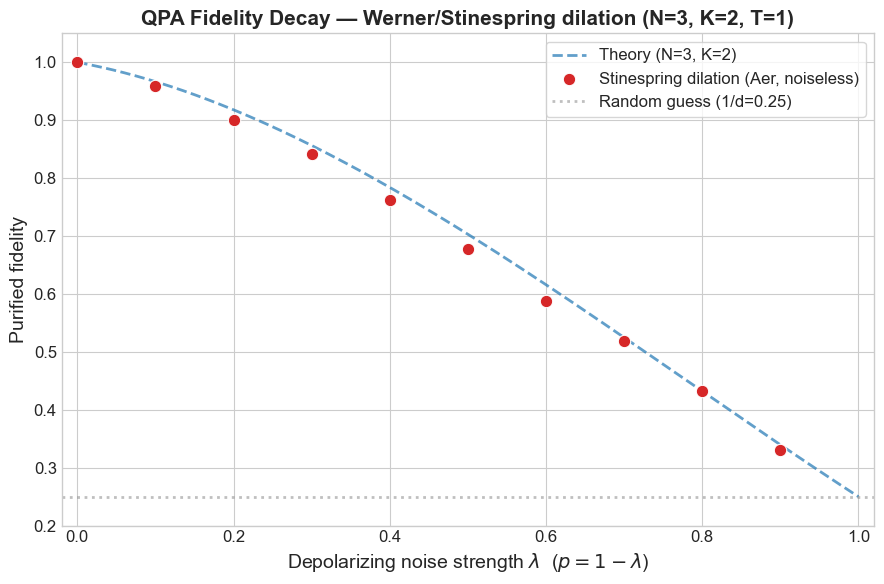

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "axes.labelsize": 14, "axes.titlesize": 15,
                     "lines.linewidth": 2, "lines.markersize": 8})

fig, ax = plt.subplots(figsize=(9, 6))
lam_fine = np.linspace(0, 1, 200)
ax.plot(lam_fine, theory_curve(lam_fine), "--", color="C0", alpha=0.7,
        label="Theory (N=3, K=2)")
ax.scatter(df["lambda"], df["fidelity"], s=80, color="C3", zorder=5,
           edgecolors="white", linewidth=0.8,
           label="Stinespring dilation (Aer, noiseless)")
ax.axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="Random guess (1/d=0.25)")
ax.set_title("QPA Fidelity Decay — Werner/Stinespring dilation (N=3, K=2, T=1)",
             fontweight="bold")
ax.set_xlabel(r"Depolarizing noise strength $\lambda$  ($p = 1-\lambda$)")
ax.set_ylabel("Purified fidelity")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.05)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "fidelity_decay_stinespring_n3.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"Plot saved to: {plot_path}")
plt.show()

## Step 8: Result Inspection

In [11]:
print(f"=== N={N}, K={K}, T={T}  (Stinespring dilation, noiseless Aer) ===")
print(f"{'lambda':>8} {'p':>6} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 52)
for _, row in df.iterrows():
    print(f"{row['lambda']:8.4f} {row['p']:6.3f} {row['fidelity']:14.4f} "
          f"{row['theory']:10.4f} {row['fidelity'] - row['theory']:+10.4f}")

mad = float(np.mean(np.abs(df["fidelity"] - df["theory"])))
print("-" * 52)
print(f"Mean |experiment - theory| = {mad:.4f}  "
      f"(expected ~ shot noise ~ 1/sqrt(SHOTS) = {1/np.sqrt(SHOTS):.4f})")

csv_path = os.path.join(RESULTS_DIR, "results_stinespring_n3.csv")
df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

=== N=3, K=2, T=1  (Stinespring dilation, noiseless Aer) ===
  lambda      p   Exp Fidelity     Theory      Delta
----------------------------------------------------
  0.0000  1.000         1.0000     1.0000    +0.0000
  0.1000  0.900         0.9596     0.9666    -0.0070
  0.2000  0.800         0.9009     0.9180    -0.0171
  0.3000  0.700         0.8414     0.8564    -0.0150
  0.4000  0.600         0.7615     0.7840    -0.0225
  0.5000  0.500         0.6781     0.7031    -0.0250
  0.6000  0.400         0.5874     0.6160    -0.0286
  0.7000  0.300         0.5179     0.5249    -0.0070
  0.8000  0.200         0.4323     0.4320    +0.0002
  0.9000  0.100         0.3307     0.3396    -0.0089
----------------------------------------------------
Mean |experiment - theory| = 0.0131  (expected ~ shot noise ~ 1/sqrt(SHOTS) = 0.0112)
Saved: sandbox/werner-stinespring/results_stinespring_n3.csv


## Step 9: Tradeoffs — Stinespring dilation vs. randomised Pauli twirling

Both methods realise the **same** per-register channel
$\rho = (1-\lambda)|0\rangle\!\langle0|^{\otimes k} + \lambda I/d$. They differ in *how*,
and the differences are what change the workflow above.

### Where the workflow diverged from the original
| Step | Original (`..._pittsburgh_t1.ipynb`) | This notebook |
|------|--------------------------------------|---------------|
| Noise injection (Step 5) | `PauliTwirlingStrategy` inserts random Paulis at the circuit front | `werner_dilation(p)` prepends an isometry onto added env qubits |
| Statistics | average over **`N_RANDOM = 5000`** circuits/λ, 3 shots each | **1** circuit/path/λ, `SHOTS` shots — all statistics from shots |
| Qubits | `N·k` data + ancilla | **+ `N·k` environment qubits** (≈ doubles the data footprint) |
| Backend (Step 2/6) | `ibm_pittsburgh`, pre-transpiled load + job submission + DD sweep | local Aer, transpile-on-the-fly |
| `ResultProcessor` | unchanged | **unchanged** (env qubits aren't measured ⇒ same readout/anc structure) |

### Advantages of the Stinespring dilation
- **Exact, not asymptotic.** Tracing out the environment gives $\rho$ *exactly* (Step 3:
  $\sim10^{-16}$). Pauli twirling only converges to $\rho$ in the `N_RANDOM → ∞` limit; at
  finite `N_RANDOM` there is residual sampling bias *on top of* shot noise.
- **Massively fewer circuits.** Per λ we submit `#paths` circuits instead of
  `#paths × N_RANDOM`. For N=3 that is **2 vs. 10 000** circuits — the whole sweep runs in
  seconds. This is the headline win for *simulation*.
- **Deterministic / reproducible.** No RNG in the noise model; a given λ always yields the
  same circuit. Easier to debug, diff, and cache.
- **Coherent, inspectable channel.** The noise is a unitary on a larger space, so you can
  read off the exact reduced state (Step 3), the purity, the full $|\Psi\rangle_{SE}$ — handy
  for validating QPA theory.

### Costs / why the production notebook still uses twirling on hardware
- **Qubit overhead.** `+k` qubits per register. N=3,K=2 here is 6 data + 6 env (+ancilla);
  the original's N=7 would need **+14** env qubits, plus the all-to-all `R_i→E_i` CNOTs
  demand favourable connectivity/SWAPs on heavy-hex hardware.
- **The cure adds the disease on real hardware.** The dilation's extra qubits and CNOTs
  have their *own* gate and idle errors, so on a device you would be injecting
  "depolarising **+** uncontrolled hardware noise on the ancillae" — no longer the clean
  channel. Pauli twirling adds only cheap single-qubit gates to the *existing* data qubits,
  which is why it is the method of choice for the IBM runs.
- **`k=2`-specific prep.** `schmidt_prep_direct` is hand-derived for `k=2`. General `k`
  needs Qiskit's `StatePreparation` of the Schmidt vector (Caio's `"stateprep"` method),
  which costs more two-qubit gates.
- **Shot-noise only, but no free averaging.** With one circuit per path, every bit of
  statistical precision comes from `SHOTS`; the twirl ensemble effectively gave 5000×3
  samples spread over noise realisations.

### Bottom line
For **noiseless / low-noise simulation** (this notebook), the Stinespring dilation is
strictly nicer: exact channel, ~3 orders of magnitude fewer circuits, deterministic. For
**real-hardware** QPA runs, randomised Pauli twirling remains preferable because it avoids
doubling the qubit count and does not contaminate the target channel with ancilla-qubit
hardware noise. The N=3 result above (points on the theory curve to within shot noise)
confirms the dilation correctly reproduces the QPA depolarising model — so it is a valid,
cheaper drop-in for the *simulation* side of the project.